In [1]:
import pandas as pd
import numpy as np


## Sarima Analysis

In [13]:
df = pd.read_csv("forecast_results_sarima_rolling.csv")

In [14]:
df.head()

,Origin,Target,Horizon,Observed,Forecast
0,2018-01,2018-02,1,0.130463,0.142851
1,2018-01,2018-03,2,0.267397,0.329512
2,2018-01,2018-04,3,0.653399,0.566055
3,2018-01,2018-05,4,1.231819,0.922253
4,2018-01,2018-06,5,2.260053,2.053449


In [15]:
df['monthp']=df['Target'].str.slice(5,7).astype(int)

In [16]:
dfa = df.groupby(["monthp","Horizon"],as_index=False)[["Observed","Forecast"]].mean()

In [17]:
dfa.head()

,monthp,Horizon,Observed,Forecast
0,1,1,0.048751,0.056169
1,1,2,0.048751,0.062539
2,1,3,0.048751,0.061780
3,1,4,0.048751,0.065549
4,1,5,0.048751,0.060464


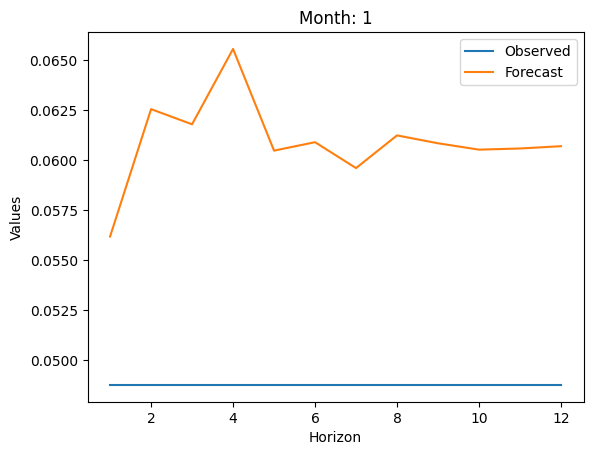

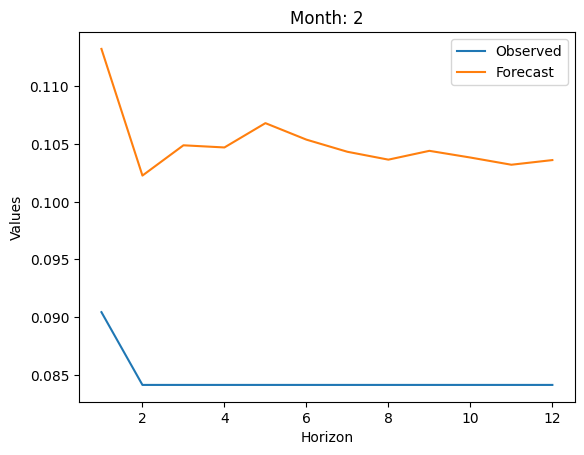

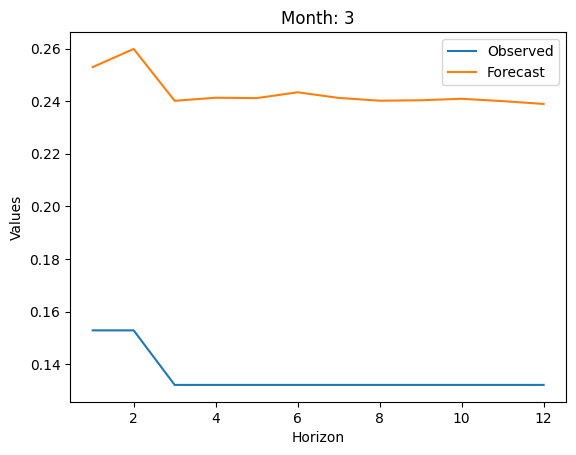

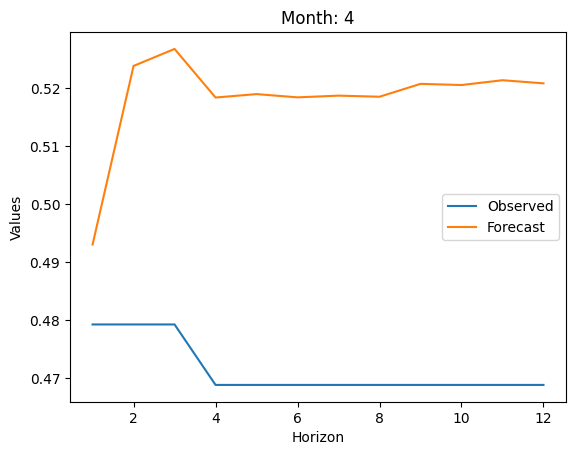

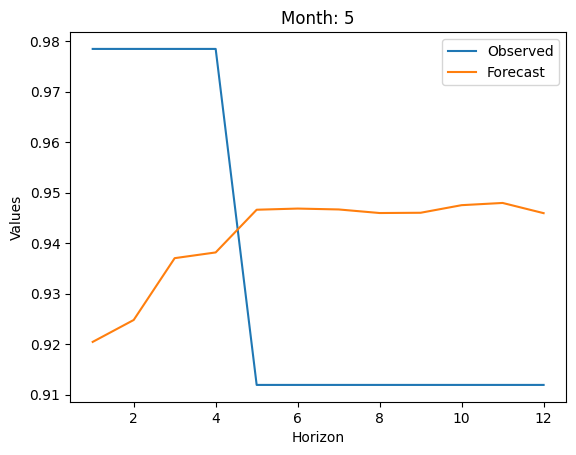

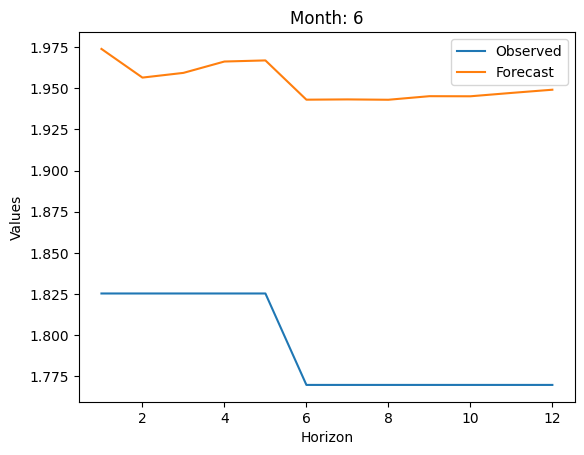

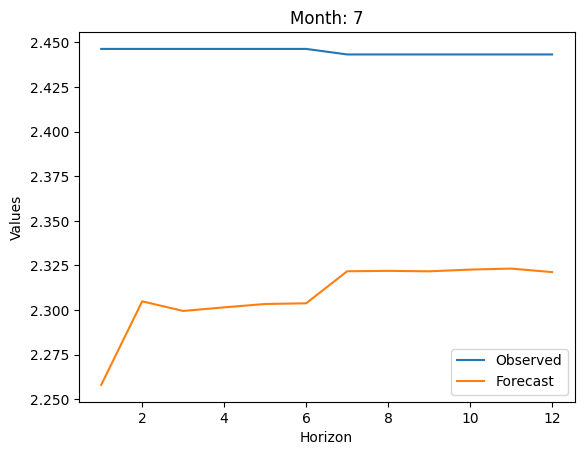

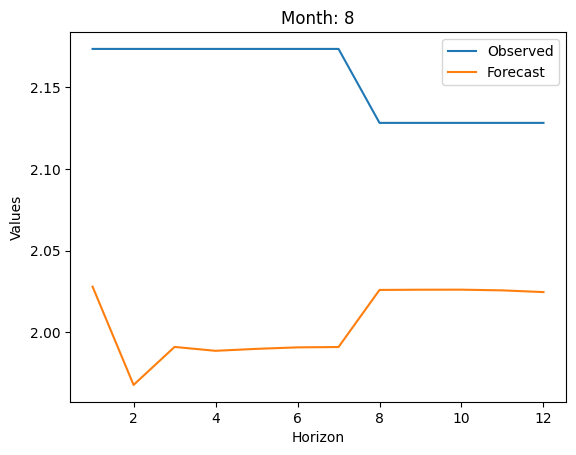

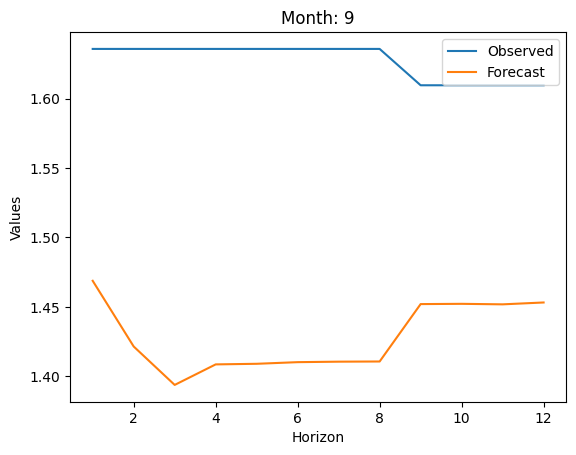

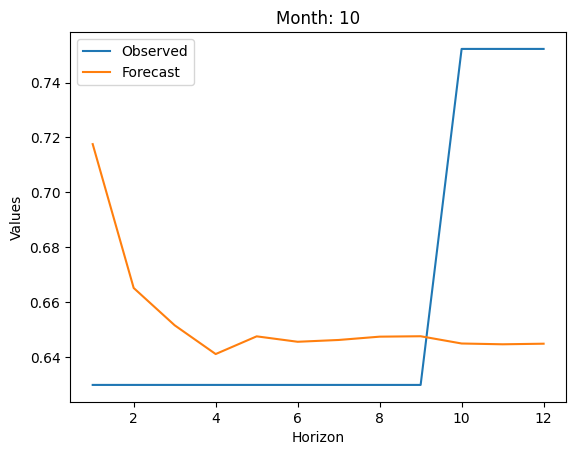

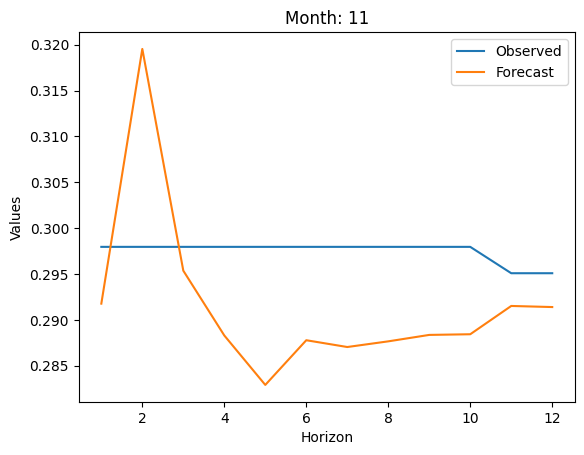

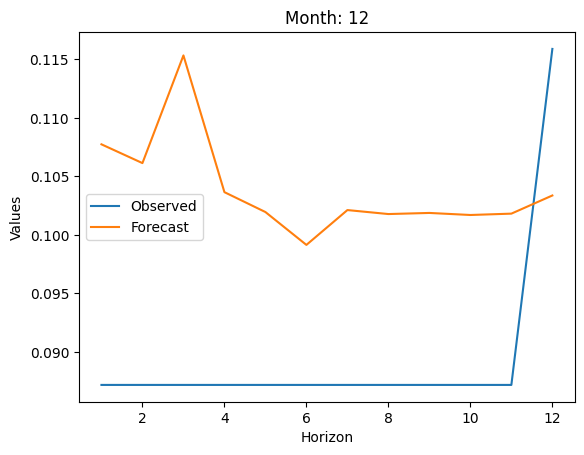

In [20]:
for month in sorted(dfa['monthp'].unique()):
    dfa_month = dfa[dfa['monthp']==month]
    dfa_month.plot(x='Horizon', y=['Observed','Forecast'], title=f'Month: {month}', ylabel='Values', xlabel='Horizon')  

In [21]:
df.head()

,Origin,Target,Horizon,Observed,Forecast,monthp
0,2018-01,2018-02,1,0.130463,0.142851,2
1,2018-01,2018-03,2,0.267397,0.329512,3
2,2018-01,2018-04,3,0.653399,0.566055,4
3,2018-01,2018-05,4,1.231819,0.922253,5
4,2018-01,2018-06,5,2.260053,2.053449,6


<Axes: xlabel='Target'>

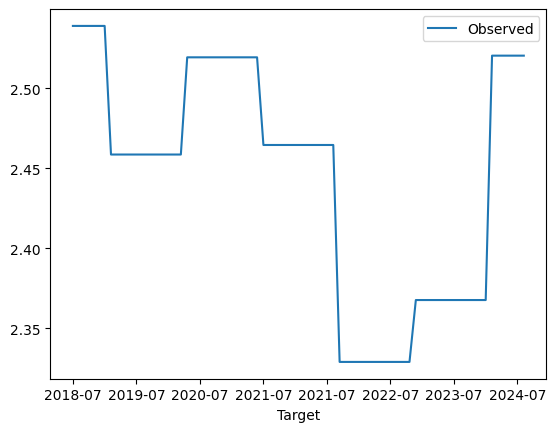

In [33]:
df.loc[df['monthp'] == 7].plot(x="Target",y=["Observed"])

In [38]:
julF = df.loc[df['monthp'] == 7]

In [37]:
df['Origin'].value_counts()

Origin
2018-01    12
2018-02    12
2018-03    12
2018-04    12
2018-05    12
           ..
2023-08    12
2023-09    12
2023-10    12
2023-11    12
2023-12    12
Name: count, Length: 72, dtype: int64

In [36]:
864/12


72.0

In [23]:
dfD = pd.read_csv("full_data.csv")

In [24]:
dfD.head()

,index,Point,Yrmo,Length,T,Td,RH,VPD,F1,F2,F3,F4,F5,F6
0,24000,500,199001,248,-8.215524,-11.944758,75.317500,0.088528,-0.352,0.18,0.68,-0.33,0.02,-1.09
1,24001,500,199002,224,-9.310223,-12.357366,78.999420,0.065388,1.151,-0.14,0.98,-0.27,0.36,-2.78
2,24002,500,199003,248,-1.306452,-5.540363,74.755806,0.171929,0.414,-0.03,0.88,-0.41,0.20,0.04
3,24003,500,199004,240,7.506708,-0.980917,57.872042,0.502332,-1.879,-1.11,0.56,-0.33,0.26,-0.62
4,24004,500,199005,248,11.061371,-4.307540,39.127258,0.946191,-1.803,2.25,0.05,-0.23,0.32,0.27


In [29]:
dfD['month'] = dfD["Yrmo"].astype(str).str[4:]
dfD['year'] = dfD["Yrmo"].astype(str).str[:4].astype(int)


In [30]:
dfD.head()

,index,Point,Yrmo,Length,T,Td,RH,VPD,F1,F2,F3,F4,F5,F6,month,year
0,24000,500,199001,248,-8.215524,-11.944758,75.317500,0.088528,-0.352,0.18,0.68,-0.33,0.02,-1.09,01,1990
1,24001,500,199002,224,-9.310223,-12.357366,78.999420,0.065388,1.151,-0.14,0.98,-0.27,0.36,-2.78,02,1990
2,24002,500,199003,248,-1.306452,-5.540363,74.755806,0.171929,0.414,-0.03,0.88,-0.41,0.20,0.04,03,1990
3,24003,500,199004,240,7.506708,-0.980917,57.872042,0.502332,-1.879,-1.11,0.56,-0.33,0.26,-0.62,04,1990
4,24004,500,199005,248,11.061371,-4.307540,39.127258,0.946191,-1.803,2.25,0.05,-0.23,0.32,0.27,05,1990


<Axes: xlabel='Yrmo'>

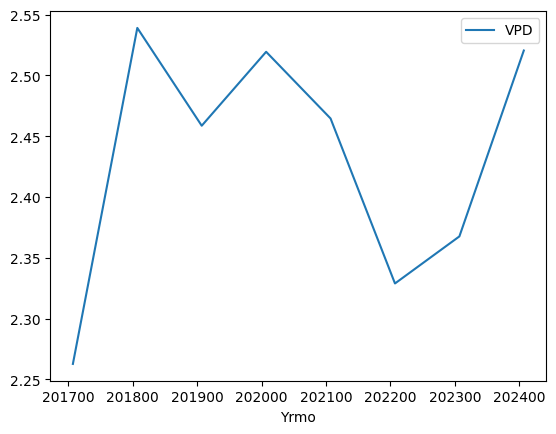

In [32]:
dfD.loc[(dfD["year"] > 2016)  & (dfD["month"] == "07")].plot(x="Yrmo",y="VPD")

In [39]:
julF.head()


,Origin,Target,Horizon,Observed,Forecast,monthp
5,2018-01,2018-07,6,2.539095,2.262779,7
16,2018-02,2018-07,5,2.539095,2.262640,7
27,2018-03,2018-07,4,2.539095,2.262434,7
38,2018-04,2018-07,3,2.539095,2.268645,7
49,2018-05,2018-07,2,2.539095,2.305198,7


In [40]:
julF.shape

(72, 6)

In [43]:
julF.groupby("Horizon")[["Observed","Forecast"]].mean()

,Observed,Forecast
Horizon,,
1,2.446366,2.257997
2,2.446366,2.304848
3,2.446366,2.299470
4,2.446366,2.301476
5,2.446366,2.303366
6,2.446366,2.303758
7,2.443266,2.321706
8,2.443266,2.321947
9,2.443266,2.321684


In [44]:
julF

,Origin,Target,Horizon,Observed,Forecast,monthp
5,2018-01,2018-07,6,2.539095,2.262779,7
16,2018-02,2018-07,5,2.539095,2.262640,7
27,2018-03,2018-07,4,2.539095,2.262434,7
38,2018-04,2018-07,3,2.539095,2.268645,7
49,2018-05,2018-07,2,2.539095,2.305198,7
...,...,...,...,...,...,...
814,2023-08,2024-07,11,2.520496,2.370743,7
825,2023-09,2024-07,10,2.520496,2.372915,7
836,2023-10,2024-07,9,2.520496,2.370011,7
847,2023-11,2024-07,8,2.520496,2.370065,7


<Axes: xlabel='Yrmo'>

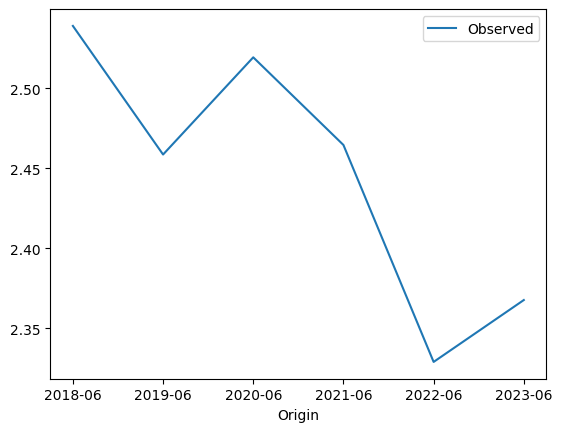

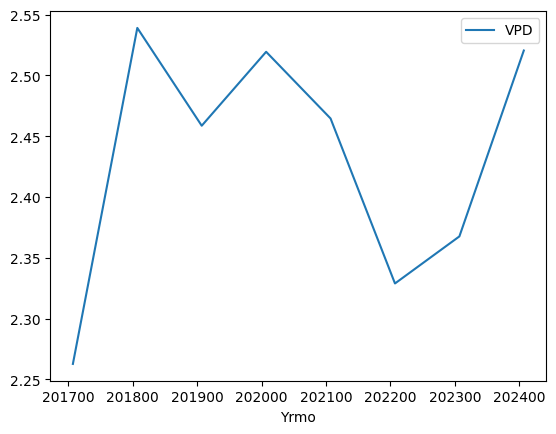

In [47]:
julF.loc[julF["Horizon"] == 1].plot(x="Origin",y=["Observed"]).plot()
dfD.loc[(dfD["year"] > 2016)  & (dfD["month"] == "07")].plot(x="Yrmo",y="VPD")


In [49]:
julF["Diff"] = julF["Observed"] - julF["Forecast"]
julF["aDiff"] = abs(julF["Observed"] - julF["Forecast"])


/tmp/ipykernel_18877/1346698913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  julF["Diff"] = julF["Observed"] - julF["Forecast"]
/tmp/ipykernel_18877/1346698913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  julF["aDiff"] = abs(julF["Observed"] - julF["Forecast"])


In [50]:
julF

,Origin,Target,Horizon,Observed,Forecast,monthp,Diff,aDiff
5,2018-01,2018-07,6,2.539095,2.262779,7,0.276317,0.276317
16,2018-02,2018-07,5,2.539095,2.262640,7,0.276455,0.276455
27,2018-03,2018-07,4,2.539095,2.262434,7,0.276661,0.276661
38,2018-04,2018-07,3,2.539095,2.268645,7,0.270450,0.270450
49,2018-05,2018-07,2,2.539095,2.305198,7,0.233897,0.233897
...,...,...,...,...,...,...,...,...
814,2023-08,2024-07,11,2.520496,2.370743,7,0.149753,0.149753
825,2023-09,2024-07,10,2.520496,2.372915,7,0.147582,0.147582
836,2023-10,2024-07,9,2.520496,2.370011,7,0.150485,0.150485
847,2023-11,2024-07,8,2.520496,2.370065,7,0.150431,0.150431


In [52]:
julF.loc[julF["Horizon"] == 1][["aDiff"]].mean()

aDiff    0.188369
dtype: float64

In [53]:
julF.groupby(["Horizon"])["aDiff"].mean()

Horizon
1     0.188369
2     0.151215
3     0.156078
4     0.154863
5     0.153345
6     0.153285
7     0.132304
8     0.132109
9     0.132139
10    0.131549
11    0.130299
12    0.133353
Name: aDiff, dtype: float64

## Fire Data

In [6]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points on Earth (in km)"""
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r



fire = pd.read_csv("FireDates.tsv",sep="\t")
latlons = pd.read_csv("latlons_42x71.csv")

locs = latlons.values.tolist()

def getLoc(row):
    lat=row['Latitude']
    lon = row['Longitude']
    dist = 10000000
    pt=-1
    tlat=-999
    tlon=-999
    for dat in locs:
        d=haversine_distance(lat,lon,dat[1],dat[2])
        
        if d < dist:
            pt=dat[0] 
            tlat=lat
            tlon=lon
            dist=d
    row["point"] = pt
    row['dist'] = dist
    row['tlat'] = tlat
    row['tlon'] = tlon
    return row

fire = fire.apply(getLoc,axis=1)
fire["point"].value_counts()


point
1316.0    10
1315.0     8
1246.0     5
1245.0     4
1317.0     3
1244.0     3
Name: count, dtype: int64

### Full Dataset

In [2]:
fireAll = pd.read_csv("FIRESTAT_Fire_Occurrence_-_Yearly_Update.csv")
fireCo=fireAll.loc[fireAll["STATE_NAME"] == "CO - COLORADO"]

/tmp/ipykernel_2042/3790920488.py:1: DtypeWarning: Columns (3,4,24,31,37,39,40,41,42,44,45,47,52,69,71,73,74,76) have mixed types. Specify dtype option on import or set low_memory=False.
  fireAll = pd.read_csv("FIRESTAT_Fire_Occurrence_-_Yearly_Update.csv")


In [3]:
for col in sorted(fireAll.columns):
    print(col)


ADMIN_UNIT
ADMIN_UNIT_NAME
AGENCY_ACRES
APPROVED_DATE
ASPECT
COMPLEX_FIRE
COMPLEX_NAME
CONTAINED
COUNTY
COUNTY_NAME
COUNTY_STATE_CODE
COVER_CLASS
CREATED_DATE
DISCOVERED_BY_DESCR
DISCOVERY
DISCOVER_YEAR
DISTRICT
ELEVATION
FIRE_DETECTOR
FIRE_INTENSITY_LEVEL
FIRE_MANAGEMENT_CODE
FIRE_NAME
FIRE_NUMBER
FIRE_OUT
FIRE_SIZE_CLASS
IGNITION
INITIAL_RESPONSE
INITIAL_STRATEGY
LAST_MODIFIED_DATE
LAT_DEG
LAT_MIN
LAT_SEC
LOCAL_FIRE_NUMBER
LOCAL_TIMEZONE
LOCATION
LONG_DEG
LONG_MIN
LONG_SEC
NFDRS_FUEL_MODEL
OBJECTID
OBJECTIVES
OTHER_ACRES_INSIDE
OTHER_ACRES_OUTSIDE
OTHER_FUEL_MODEL
OWNERSHIP_AGENCY_AT_ORIGIN
OWNERSHIP_UNIT
OWNERSHIP_UNIT_NAME
POO_LATITUDE
POO_LONGITUDE
PRESCRIBED_ACRES
PRESCRIBED_FIRE
PRINCIPAL_MERIDIAN
PROTECTING_AGENCY_AT_ORIGIN
PROTECTION_UNIT
PROTECTION_UNIT_NAME
RANGE
RECORD_ENTRY_DATE
REPORT_UNIT
REPORT_UNIT_NAME
REP_WX_STATION
SECTION
SHAPE
SLOPE
STATE_CODE
STATE_NAME
STATION_NAME
STATION_TYPE
STATISTICAL_CAUSE
STRATEGY_MET
SUBMITTED_DATE
SUB_SECTION
TOPO_LANDFORM_ORIGIN
TOTAL_

In [5]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points on Earth (in km)"""
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r


def getLoc(row):
    lat=row['POO_LATITUDE']
    lon = row['POO_LONGITUDE']
    dist = 10000000
    pt=-1
    tlat=-999
    tlon=-999
    for dat in locs:
        d=haversine_distance(lat,lon,dat[1],dat[2])
        
        if d < dist:
            pt=dat[0] 
            tlat=lat
            tlon=lon
            dist=d
    row["point"] = pt
    row['dist'] = dist
    row['tlat'] = tlat
    row['tlon'] = tlon
    return row
latlons = pd.read_csv("latlons_42x71.csv")

locs = latlons.values.tolist()
fireCo = fireCo.apply(getLoc,axis=1)
fireCo["point"].value_counts()


point
1316.0    166
1531.0    150
2716.0    150
1459.0    148
2568.0    141
         ... 
1790.0      1
2430.0      1
2931.0      1
2393.0      1
1513.0      1
Name: count, Length: 1122, dtype: int64

In [ ]:
fireCo['FIRE_NAME'].value_counts().to_dict()

In [89]:
fireCo.columns

Index(['X', 'Y', 'OBJECTID', 'DISCOVER_YEAR', 'FIRE_NUMBER', 'COUNTY',
       'TOTAL_ACRES_BURNED', 'TOPO_LANDFORM_ORIGIN', 'PRESCRIBED_FIRE',
       'SLOPE', 'ELEVATION', 'OTHER_FUEL_MODEL', 'REP_WX_STATION', 'LAT_DEG',
       'LAT_MIN', 'LAT_SEC', 'LONG_DEG', 'LONG_MIN', 'LONG_SEC', 'TOWNSHIP',
       'RANGE', 'SECTION', 'SUB_SECTION', 'WIND_SPEED', 'DISCOVERED_BY_DESCR',
       'FIRE_NAME', 'RECORD_ENTRY_DATE', 'AGENCY_ACRES', 'OTHER_ACRES_INSIDE',
       'OTHER_ACRES_OUTSIDE', 'DISTRICT', 'LOCAL_FIRE_NUMBER',
       'PRESCRIBED_ACRES', 'IGNITION', 'DISCOVERY', 'STRATEGY_MET', 'FIRE_OUT',
       'SUBMITTED_DATE', 'APPROVED_DATE', 'STATE_CODE', 'CONTAINED',
       'COUNTY_STATE_CODE', 'LOCATION', 'FIRE_MANAGEMENT_CODE', 'COMPLEX_FIRE',
       'WUI_FIRE', 'WUI_ACRES', 'OBJECTIVES', 'CREATED_DATE',
       'LAST_MODIFIED_DATE', 'POO_LATITUDE', 'POO_LONGITUDE', 'COMPLEX_NAME',
       'STATION_TYPE', 'STATION_NAME', 'ASPECT', 'PRINCIPAL_MERIDIAN',
       'STATISTICAL_CAUSE', 'FIRE_SIZE_CL

## Fire Dates vs Data

In [52]:
climate = pd.read_csv(f"full_data_point_1316.csv")
climate['Month']=climate['Yrmo'].astype(str).str[4:].astype(int)
climate['Year']=climate['Yrmo'].astype(str).str[:4].astype
means=climate.groupby("Month",as_index=False)[["T","Td","VPD"]].mean()
stds=climate.groupby("Month",as_index=False)[["T","Td","VPD"]].std()

climate["VPD Mean"]=climate['Month'].map(means.set_index('Month')['VPD'])
climate["VPD Std"]=climate['Month'].map(stds.set_index('Month')['VPD'])

climate['VPD Departure'] = climate['VPD'] - climate['Month'].map(means.set_index('Month')['VPD'])
climate['VPD Zscore'] = (climate['VPD Departure']) / climate['VPD Std']

In [ ]:
climate.head()

In [54]:
ff=fire.loc[fire['point']==1316]
ff["Yrmo"]=ff['Date of Ignition'].str[:4]+ff['Date of Ignition'].str[5:7]
ff["Yrmo"]=ff['Yrmo'].astype(int)

ff=pd.merge(ff,climate,on="Yrmo",how="inner")

/tmp/ipykernel_1973/3532940831.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ff["Yrmo"]=ff['Date of Ignition'].str[:4]+ff['Date of Ignition'].str[5:7]
/tmp/ipykernel_1973/3532940831.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ff["Yrmo"]=ff['Yrmo'].astype(int)


In [55]:
ff

,OBJECTID,Longitude,Latitude,DISCOVER_YEAR,Date of Ignition,point,dist,tlat,tlon,Yrmo,...,F3,F4,F5,F6,Month,Year,VPD Mean,VPD Std,VPD Departure,VPD Zscore
0,417770984,-105.179420,39.315000,2017,2017/06/22 17:00:00+00,1316.0,2.432531,39.315000,-105.179420,201706,...,0.22,0.20,0.22,1.18,6,<bound method NDFrame.astype of 0 1990\n1...,1.039532,0.293196,0.100420,0.342502
1,417774492,-105.235900,39.343942,2018,2018/06/14 08:00:00+00,1316.0,5.780171,39.343942,-105.235900,201806,...,0.80,-0.47,0.12,0.66,6,<bound method NDFrame.astype of 0 1990\n1...,1.039532,0.293196,0.428797,1.462495
2,417779957,-105.207317,39.326050,2017,2017/06/06 13:00:00+00,1316.0,2.964233,39.326050,-105.207317,201706,...,0.22,0.20,0.22,1.18,6,<bound method NDFrame.astype of 0 1990\n1...,1.039532,0.293196,0.100420,0.342502
3,417783012,-105.195297,39.299000,2019,2019/06/05 14:00:00+00,1316.0,0.419664,39.299000,-105.195297,201906,...,0.07,-0.11,0.66,0.24,6,<bound method NDFrame.astype of 0 1990\n1...,1.039532,0.293196,-0.247935,-0.845630
4,417824402,-105.182100,39.341900,2019,2019/09/05 13:00:00+00,1316.0,4.906917,39.341900,-105.182100,201909,...,0.09,-0.68,0.11,1.62,9,<bound method NDFrame.astype of 0 1990\n1...,0.878232,0.207026,0.429841,2.076268
5,417866655,-105.209183,39.298550,2017,2017/02/05 12:30:00+00,1316.0,0.806486,39.298550,-105.209183,201702,...,0.30,0.92,-0.01,-0.05,2,<bound method NDFrame.astype of 0 1990\n1...,0.173474,0.045111,0.054533,1.208859
6,417867895,-105.169900,39.300992,2018,2018/05/20 18:00:00+00,1316.0,2.592346,39.300992,-105.169900,201805,...,0.75,-0.46,-0.12,-1.09,5,<bound method NDFrame.astype of 0 1990\n1...,0.574167,0.144301,0.179314,1.242635
7,417869595,-105.205200,39.297069,2019,2019/01/08 13:00:00+00,1316.0,0.553536,39.297069,-105.205200,201901,...,0.77,0.67,0.51,0.42,1,<bound method NDFrame.astype of 0 1990\n1...,0.139451,0.041134,-0.021582,-0.524671
8,417874404,-105.186997,39.327500,2017,2017/08/15 10:00:00+00,1316.0,3.256048,39.327500,-105.186997,201708,...,-0.21,-0.76,-0.18,0.20,8,<bound method NDFrame.astype of 0 1990\n1...,0.987245,0.229645,-0.076767,-0.334286
9,417874427,-105.153000,39.299161,2018,2018/07/03 17:00:00+00,1316.0,4.045314,39.299161,-105.153000,201807,...,0.73,-0.08,0.27,-0.76,7,<bound method NDFrame.astype of 0 1990\n1...,1.143429,0.260620,0.064125,0.246049


### Full Dataset

In [58]:
fireAll = pd.read_csv("FIRESTAT_Fire_Occurrence_-_Yearly_Update.csv")

/tmp/ipykernel_1973/50517139.py:1: DtypeWarning: Columns (3,4,24,31,37,39,40,41,42,44,45,47,52,69,71,73,74,76) have mixed types. Specify dtype option on import or set low_memory=False.
  fireAll = pd.read_csv("FIRESTAT_Fire_Occurrence_-_Yearly_Update.csv")


In [61]:
for col in sorted(fireAll.columns):
    print(col)


ADMIN_UNIT
ADMIN_UNIT_NAME
AGENCY_ACRES
APPROVED_DATE
ASPECT
COMPLEX_FIRE
COMPLEX_NAME
CONTAINED
COUNTY
COUNTY_NAME
COUNTY_STATE_CODE
COVER_CLASS
CREATED_DATE
DISCOVERED_BY_DESCR
DISCOVERY
DISCOVER_YEAR
DISTRICT
ELEVATION
FIRE_DETECTOR
FIRE_INTENSITY_LEVEL
FIRE_MANAGEMENT_CODE
FIRE_NAME
FIRE_NUMBER
FIRE_OUT
FIRE_SIZE_CLASS
IGNITION
INITIAL_RESPONSE
INITIAL_STRATEGY
LAST_MODIFIED_DATE
LAT_DEG
LAT_MIN
LAT_SEC
LOCAL_FIRE_NUMBER
LOCAL_TIMEZONE
LOCATION
LONG_DEG
LONG_MIN
LONG_SEC
NFDRS_FUEL_MODEL
OBJECTID
OBJECTIVES
OTHER_ACRES_INSIDE
OTHER_ACRES_OUTSIDE
OTHER_FUEL_MODEL
OWNERSHIP_AGENCY_AT_ORIGIN
OWNERSHIP_UNIT
OWNERSHIP_UNIT_NAME
POO_LATITUDE
POO_LONGITUDE
PRESCRIBED_ACRES
PRESCRIBED_FIRE
PRINCIPAL_MERIDIAN
PROTECTING_AGENCY_AT_ORIGIN
PROTECTION_UNIT
PROTECTION_UNIT_NAME
RANGE
RECORD_ENTRY_DATE
REPORT_UNIT
REPORT_UNIT_NAME
REP_WX_STATION
SECTION
SHAPE
SLOPE
STATE_CODE
STATE_NAME
STATION_NAME
STATION_TYPE
STATISTICAL_CAUSE
STRATEGY_MET
SUBMITTED_DATE
SUB_SECTION
TOPO_LANDFORM_ORIGIN
TOTAL_

In [79]:
fireCo=fireAll.loc[fireAll["STATE_NAME"] == "CO - COLORADO"]

In [ ]:
fireCo['FIRE_NAME'].value_counts().to_dict()

In [78]:
fireCo.columns

Index(['CREATED_DATE', 'DISCOVER_YEAR'], dtype='object')

In [85]:
fireCo.loc[fireCo['FIRE_NAME'].str.strip() == "SPRING CREEK",["POO_LATITUDE","POO_LONGITUDE","DISCOVERY","DISCOVER_YEAR"]]

,POO_LATITUDE,POO_LONGITUDE,DISCOVERY,DISCOVER_YEAR
24573,37.496667,-108.228333,1972/08/11 09:30:00+00,1972
24668,38.315833,-107.989444,2003/05/31 14:31:00+00,2003
24867,37.503611,-108.231111,1970/07/07 07:00:00+00,1970
24986,37.141944,-107.511944,1978/08/09 10:30:00+00,1978
34857,37.161667,-107.457778,2008/07/01 16:00:00+00,2008
40863,37.213611,-107.461667,1964/07/12 13:25:00+00,1964
87428,39.138056,-106.253889,2007/10/24 18:30:00+00,2007
102966,38.069444,-107.010556,2009/07/21 19:36:00+00,2009
104527,37.656667,-108.174444,1961/07/28 18:30:00+00,1961
104611,37.195833,-107.464444,1964/08/03 08:43:00+00,1964
